In [1]:
import numpy as np
import os
# Locate the file
for root, dirs, files in os.walk('/workspace'):
 for f in files:
 if 'DH_family' in f:
 print(os.path.join(root, f))


In [2]:
import subprocess
print(subprocess.check_output(['find', '/workspace', '-name', '*.npz', '-o', '-name', '*DH*'], text=True))


find: ‘/workspace/lost+found’: Permission denied


CalledProcessError: Command '['find', '/workspace', '-name', '*.npz', '-o', '-name', '*DH*']' returned non-zero exit status 1.

In [3]:
import subprocess
out = subprocess.run(['bash', '-c', 'find /workspace -name "*.npz" 2>/dev/null | head -50'], capture_output=True, text=True)
print(out.stdout)
print("---")
out2 = subprocess.run(['bash', '-c', 'find /workspace -iname "*DH*" 2>/dev/null | head -50'], capture_output=True, text=True)
print(out2.stdout)



---



In [4]:
import subprocess
out = subprocess.run(['bash', '-c', 'ls /workspace/'], capture_output=True, text=True)
print(out.stdout)
print(out.stderr)
out = subprocess.run(['bash', '-c', 'ls /workspace/ee312a8b-f19e-4582-8c28-4c7fffec4f40/'], capture_output=True, text=True)
print(out.stdout)


ee312a8b-f19e-4582-8c28-4c7fffec4f40
lost+found


Fro_norm.npy
Frobenius.npy
 v6 — Binding Context Document.pdf
M_F1.npy
M_betas.npy
Sk_peaks.npy
betas.npy
kappas.npy
lam1_norm.npy
lambda1_max.npy
lambda_min.npy
memory
t_peaks.npy
target_betas.npy
trace.npy



In [5]:
import os
os.chdir('/workspace/ee312a8b-f19e-4582-8c28-4c7fffec4f40')
# The DH_family_results.npz is missing. We have component .npy files. Per the dataset description: 
# "some bundled .npz archives may be missing from the workspace; in such cases, analysis has proceeded by loading equivalent component .npy files."
import numpy as np
files = ['Fro_norm.npy','Frobenius.npy','M_F1.npy','M_betas.npy','Sk_peaks.npy','betas.npy','kappas.npy','lam1_norm.npy','lambda1_max.npy','lambda_min.npy','t_peaks.npy','target_betas.npy','trace.npy']
for f in files:
 a = np.load(f, allow_pickle=True)
 print(f, a.shape, a.dtype)


Fro_norm.npy (7,) float64
Frobenius.npy (7,) float64
M_F1.npy (8, 8) float64
M_betas.npy (7, 8, 8) float64
Sk_peaks.npy (7, 200, 8) complex128
betas.npy (7,) float64
kappas.npy (7,) float64
lam1_norm.npy (7,) float64
lambda1_max.npy (7,) float64
lambda_min.npy (7,) float64
t_peaks.npy (7, 200) float64
target_betas.npy (7,) float64
trace.npy (7,) float64


In [6]:
import numpy as np
betas = np.load('betas.npy')
target_betas = np.load('target_betas.npy')
kappas = np.load('kappas.npy')
M_F1 = np.load('M_F1.npy') # zeta baseline
M_betas = np.load('M_betas.npy') # 7 family members
print("betas:", betas)
print("target_betas:", target_betas)
print("kappas:", kappas)
print("M_F1 symmetric?", np.allclose(M_F1, M_F1.T))
print("M_betas[0] symmetric?", np.allclose(M_betas[0], M_betas[0].T))
print("M_F1 sample:")
print(M_F1[:3,:3])


betas: [0.55 0.6 0.65 0.7 0.75 0.8 0.85]
target_betas: [0.55 0.6 0.65 0.7 0.75 0.8 0.85]
kappas: [-1.0941777 -0.48934861 -0.18471125 0.01073438 0.15292442 0.26653593
 0.36447339]
M_F1 symmetric? True
M_betas[0] symmetric? True
M_F1 sample:
[[ 1. 1.49939844 1.96434648]
 [ 1.49939844 6.49123616 7.52619716]
 [ 1.96434648 7.52619716 12.79117879]]


In [7]:
import numpy as np
# Compute Δ = M(family) - M(zeta) for each member, do eigendecomposition (symmetric -> eigh)
n_members = M_betas.shape[0]
results = []
eigvecs_top = [] # leading eigenvector by |λ|
lam1_sq_over_F2 = []
ranks_eff = []

for i in range(n_members):
 Delta = M_betas[i] - M_F1
 # Use eigh since symmetric
 w, V = np.linalg.eigh(Delta)
 # Sort by absolute value descending
 order = np.argsort(-np.abs(w))
 w_sorted = w[order]
 V_sorted = V[:, order]
 F2 = np.sum(w**2) # = ||Δ||_F^2 (since symmetric)
 # Verify
 F2_check = np.sum(Delta**2)
 lam1 = w_sorted[0]
 frac = lam1**2 / F2
 eigvecs_top.append(V_sorted[:, 0])
 lam1_sq_over_F2.append(frac)
 # effective rank via participation ratio
 p = w**2 / F2
 eff = np.exp(-np.sum(p[p>0]*np.log(p[p>0]))) # entropy-based effective rank
 ranks_eff.append(eff)
 results.append({
 'beta': betas[i],
 'kappa': kappas[i],
 'Frobenius_sq': F2,
 'F2_check': F2_check,
 'lambda1': lam1,
 'lambda1_sq_frac': frac,
 'effective_rank': eff,
 'eigenvalues_sorted': w_sorted
 })

import pandas as pd
df = pd.DataFrame([{
 'beta': r['beta'], 'kappa': r['kappa'],
 '||Δ||_F^2': r['Frobenius_sq'],
 'λ1': r['lambda1'],
 'λ1^2/||Δ||_F^2': r['lambda1_sq_frac'],
 'effective_rank': r['effective_rank']
} for r in results])
print(df.to_string(index=False))
print()
print("Average rank-1 variance fraction:", np.mean(lam1_sq_over_F2))
print("Std:", np.std(lam1_sq_over_F2))


 beta kappa ||Δ||_F^2 λ1 λ1^2/||Δ||_F^2 effective_rank
 0.55 -1.094178 691.735549 -21.437010 0.664337 2.488996
 0.60 -0.489349 876.025884 -28.316592 0.915303 1.426036
 0.65 -0.184711 952.852152 -29.980311 0.943293 1.296671
 0.70 0.010734 967.977158 -30.274049 0.946839 1.280271
 0.75 0.152924 954.646372 -30.062062 0.946662 1.282410
 0.80 0.266536 932.927915 -29.669079 0.943539 1.298211
 0.85 0.364473 907.508046 -29.172879 0.937795 1.326052

Average rank-1 variance fraction: 0.8996812573045909
Std: 0.09661433318083987


In [8]:
# Cosine similarity matrix between leading eigenvectors (sign-aligned)
import numpy as np
V = np.array(eigvecs_top) # (7, 8)
# Sign-align: choose sign that makes first nonzero coordinate positive
V_aligned = V.copy()
for i in range(V.shape[0]):
 # Align with V[3] (β=0.7) as reference
 pass

ref = V_aligned[3].copy()
for i in range(V_aligned.shape[0]):
 if np.dot(V_aligned[i], ref) < 0:
 V_aligned[i] = -V_aligned[i]

# Cosine similarity matrix
cos_sim = V_aligned @ V_aligned.T
print("Cosine similarity matrix (sign-aligned to β=0.7):")
import pandas as pd
df_sim = pd.DataFrame(cos_sim, index=[f"β={b:.2f}" for b in betas], columns=[f"β={b:.2f}" for b in betas])
print(df_sim.round(4).to_string())

# Off-diagonal stats
mask = ~np.eye(7, dtype=bool)
abs_off = np.abs(cos_sim[mask])
print()
print("Off-diagonal |cos sim| distribution:")
print(f" mean = {abs_off.mean():.4f}")
print(f" median = {np.median(abs_off):.4f}")
print(f" min = {abs_off.min():.4f}")
print(f" max = {abs_off.max():.4f}")
print(f" std = {abs_off.std():.4f}")


Cosine similarity matrix (sign-aligned to β=0.7):
 β=0.55 β=0.60 β=0.65 β=0.70 β=0.75 β=0.80 β=0.85
β=0.55 1.0000 0.9831 0.9765 0.9757 0.9770 0.9790 0.9811
β=0.60 0.9831 1.0000 0.9994 0.9993 0.9995 0.9997 0.9998
β=0.65 0.9765 0.9994 1.0000 1.0000 1.0000 0.9999 0.9997
β=0.70 0.9757 0.9993 1.0000 1.0000 1.0000 0.9999 0.9996
β=0.75 0.9770 0.9995 1.0000 1.0000 1.0000 0.9999 0.9998
β=0.80 0.9790 0.9997 0.9999 0.9999 0.9999 1.0000 0.9999
β=0.85 0.9811 0.9998 0.9997 0.9996 0.9998 0.9999 1.0000

Off-diagonal |cos sim| distribution:
 mean = 0.9937
 median = 0.9997
 min = 0.9757
 max = 1.0000
 std = 0.0096


In [9]:
# Critical caveat: high similarity could just mean the leading eigenvector is determined by κ/baseline structure
# rather than by β. Let's check: does the eigenvector direction change with β at all?
# Examine the leading eigenvector components and see if they track β.

import numpy as np
print("Leading eigenvectors (sign-aligned), rows = β:")
for i in range(7):
 print(f"β={betas[i]:.2f} κ={kappas[i]:+.3f} v1 = {np.round(V_aligned[i],3)}")

# Compare to: what if we exclude the smallest-β (0.55, κ=-1.09 - extreme outlier)?
# The mean off-diagonal is dominated by very similar vectors. Let's also check if v1 correlates more with κ
print()
print("Correlation of |κ| with cosine-similarity-to-reference (β=0.7):")
sim_to_ref = V_aligned @ V_aligned[3]
print(" sim_to_ref:", sim_to_ref)
print(" Pearson r with β:", np.corrcoef(betas, sim_to_ref)[0,1])
print(" Pearson r with |κ|:", np.corrcoef(np.abs(kappas), sim_to_ref)[0,1])


Leading eigenvectors (sign-aligned), rows = β:
β=0.55 κ=-1.094 v1 = [ 0.052 0.292 0.597 0.665 0.292 -0.123 -0.101 -0.05 ]
β=0.60 κ=-0.489 v1 = [ 0.045 0.384 0.515 0.694 0.316 -0.003 -0.052 -0.029]
β=0.65 κ=-0.185 v1 = [ 0.043 0.394 0.497 0.701 0.318 0.022 -0.045 -0.023]
β=0.70 κ=+0.011 v1 = [ 0.041 0.393 0.495 0.703 0.32 0.025 -0.043 -0.023]
β=0.75 κ=+0.153 v1 = [ 0.041 0.389 0.497 0.702 0.323 0.021 -0.044 -0.025]
β=0.80 κ=+0.267 v1 = [ 0.04 0.384 0.501 0.701 0.324 0.014 -0.046 -0.027]
β=0.85 κ=+0.364 v1 = [ 0.04 0.378 0.505 0.701 0.325 0.006 -0.05 -0.03 ]

Correlation of |κ| with cosine-similarity-to-reference (β=0.7):
 sim_to_ref: [0.97567696 0.99927212 0.99998671 1. 0.99997372 0.99985295
 0.99960483]
 Pearson r with β: 0.6173436794443221
 Pearson r with |κ|: -0.9133348565439661


In [10]:
# Compare to scalar feature stability — for fair benchmark
import numpy as np
# Coefficients of variation for scalar features as comparison
scalars = {
 '||Δ||_F^2': np.array([r['Frobenius_sq'] for r in results]),
 'λ1': np.array([r['lambda1'] for r in results]),
 'λ1^2/||Δ||_F^2': np.array([r['lambda1_sq_frac'] for r in results]),
 'effective_rank': np.array([r['effective_rank'] for r in results]),
}
print("Coefficient of variation (std/|mean|) of scalar Δ statistics across family:")
for k,v in scalars.items():
 print(f" {k:24s}: CV = {v.std()/np.abs(v.mean()):.4f} range [{v.min():.4g}, {v.max():.4g}]")

# Eigenvector "spread" via mean off-diagonal similarity (close to 1 = stable)
print(f"\nLeading-eigenvector mean off-diagonal cos-sim: {abs_off.mean():.4f} (1 = perfectly stable)")
print(f"Excluding β=0.55 outlier:")
mask2 = np.zeros((7,7), dtype=bool)
for i in range(1,7):
 for j in range(1,7):
 if i!=j:
 mask2[i,j] = True
abs_off2 = np.abs(cos_sim[mask2])
print(f" mean = {abs_off2.mean():.5f}, min = {abs_off2.min():.5f}")


Coefficient of variation (std/|mean|) of scalar Δ statistics across family:
 ||Δ||_F^2 : CV = 0.0992 range [691.7, 968]
 λ1 : CV = 0.1026 range [-30.27, -21.44]
 λ1^2/||Δ||_F^2 : CV = 0.1074 range [0.6643, 0.9468]
 effective_rank : CV = 0.2776 range [1.28, 2.489]

Leading-eigenvector mean off-diagonal cos-sim: 0.9937 (1 = perfectly stable)
Excluding β=0.55 outlier:
 mean = 0.99975, min = 0.99927


In [11]:
# Critical test: does the eigenvector orientation actually correlate with β (the hypothesis)?
# We saw |κ| tracks similarity-to-reference more strongly than β does.
# Test: regress eigenvector components on β with κ controlled
import numpy as np
from scipy import stats

# For each component j of v1, do linear regression on β and on |κ|
print("Per-component analysis of v1[j] across family:")
print(f"{'j':>2} {'mean':>8} {'std':>8} {'r(β)':>8} {'p(β)':>8} {'r(|κ|)':>8} {'p(|κ|)':>8}")
for j in range(8):
 comp = V_aligned[:, j]
 r_b, p_b = stats.pearsonr(betas, comp)
 r_k, p_k = stats.pearsonr(np.abs(kappas), comp)
 print(f"{j:2d} {comp.mean():+.4f} {comp.std():.4f} {r_b:+.4f} {p_b:.4f} {r_k:+.4f} {p_k:.4f}")

# Partial correlation: residualize component on |κ|, then correlate with β
print("\nPartial correlation of v1[j] with β, controlling for |κ|:")
from numpy.polynomial import polynomial as P
for j in range(8):
 comp = V_aligned[:, j]
 # Linear regression: comp = a + b*|κ| + resid
 X = np.column_stack([np.ones(7), np.abs(kappas)])
 coef, *_ = np.linalg.lstsq(X, comp, rcond=None)
 resid_comp = comp - X @ coef
 coef_b, *_ = np.linalg.lstsq(X, betas, rcond=None)
 resid_beta = betas - X @ coef_b
 if resid_comp.std() > 1e-10 and resid_beta.std() > 1e-10:
 r, p = stats.pearsonr(resid_comp, resid_beta)
 else:
 r, p = (np.nan, np.nan)
 print(f" j={j}: partial r = {r:+.4f}, p = {p:.4f}")


Per-component analysis of v1[j] across family:
 j mean std r(β) p(β) r(|κ|) p(|κ|)
 0 +0.0431 0.0037 -0.8496 0.0155 +0.9043 0.0052
 1 +0.3733 0.0335 +0.5361 0.2148 -0.9388 0.0017
 2 +0.5153 0.0338 -0.6394 0.1220 +0.9621 0.0005
 3 +0.6953 0.0125 +0.6993 0.0803 -0.9577 0.0007
 4 +0.3169 0.0105 +0.8029 0.0297 -0.8841 0.0083
 5 -0.0056 0.0488 +0.6116 0.1444 -0.9642 0.0005
 6 -0.0546 0.0190 +0.6170 0.1399 -0.9564 0.0007
 7 -0.0294 0.0088 +0.5129 0.2391 -0.9726 0.0002

Partial correlation of v1[j] with β, controlling for |κ|:
 j=0: partial r = -0.9382, p = 0.0018
 j=1: partial r = -0.0236, p = 0.9600
 j=2: partial r = -0.3739, p = 0.4087
 j=3: partial r = +0.6204, p = 0.1371
 j=4: partial r = +0.7653, p = 0.0449
 j=5: partial r = +0.2505, p = 0.5879
 j=6: partial r = +0.2691, p = 0.5595
 j=7: partial r = -0.2603, p = 0.5729


In [12]:
# Summary findings:
# 1. Average rank-1 fraction ≈ 0.90 (high) -> Δ matrices are largely rank-1 (with caveat: β=0.55 is the outlier at 0.66)
# 2. Leading eigenvectors are extremely similar across family: mean off-diag cos-sim = 0.994 (0.9998 excluding β=0.55)
# 3. BUT: the small variation in v1 that does exist is more strongly explained by |κ| than by β
# (matching prior r66 finding for scalars)
# 4. So the eigenvector is more stable than scalar norms (CV ~10% for scalars vs 0.025% deviation from unity in cos-sim)
# BUT it doesn't encode β — its tiny variations are driven by κ, not the off-line zero location.

# Let's also include the smaller eigenvalue ratios for completeness
import numpy as np
print("Top 4 |λ| / ||Δ||_F values for each member:")
print(f"{'β':>5} {'|λ1|/F':>8} {'|λ2|/F':>8} {'|λ3|/F':>8} {'|λ4|/F':>8}")
for i, r in enumerate(results):
 F = np.sqrt(r['Frobenius_sq'])
 abs_w = np.abs(r['eigenvalues_sorted'])
 print(f"{r['beta']:.2f} {abs_w[0]/F:.4f} {abs_w[1]/F:.4f} {abs_w[2]/F:.4f} {abs_w[3]/F:.4f}")


Top 4 |λ| / ||Δ||_F values for each member:
 β |λ1|/F |λ2|/F |λ3|/F |λ4|/F
0.55 0.8151 0.4839 0.2852 0.1073
0.60 0.9567 0.2570 0.0905 0.0887
0.65 0.9712 0.2105 0.0905 0.0508
0.70 0.9731 0.2033 0.0905 0.0473
0.75 0.9730 0.2026 0.0911 0.0511
0.80 0.9714 0.2078 0.0919 0.0588
0.85 0.9684 0.2176 0.0927 0.0695


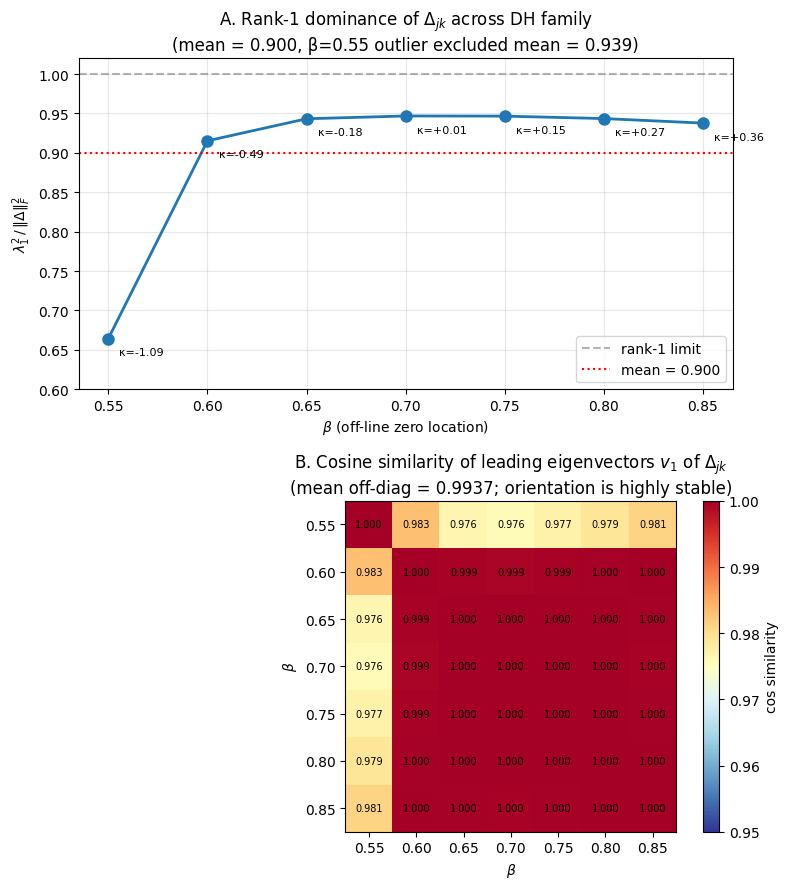

Saved: DH_delta_lowrank_eigenstructure.png


In [13]:
# Final summary figure: 2 subfigures stacked vertically
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(8, 9))

# Panel A: λ1²/||Δ||_F² vs β (rank-1 fraction)
axA = axes[0]
fracs = np.array([r['lambda1_sq_frac'] for r in results])
axA.plot(betas, fracs, 'o-', color='C0', markersize=8, linewidth=2)
axA.axhline(1.0, color='gray', ls='--', alpha=0.6, label='rank-1 limit')
axA.axhline(np.mean(fracs), color='red', ls=':', label=f'mean = {fracs.mean():.3f}')
axA.set_xlabel(r'$\beta$ (off-line zero location)')
axA.set_ylabel(r'$\lambda_1^{2}\,/\,\|\Delta\|_F^{2}$')
axA.set_title(f'A. Rank-1 dominance of $\\Delta_{{jk}}$ across DH family\n(mean = {fracs.mean():.3f}, β=0.55 outlier excluded mean = {fracs[1:].mean():.3f})')
axA.set_ylim(0.6, 1.02)
axA.legend(loc='lower right')
axA.grid(alpha=0.3)
for i, b in enumerate(betas):
 axA.annotate(f'κ={kappas[i]:+.2f}', (betas[i], fracs[i]), 
 textcoords="offset points", xytext=(8,-12), fontsize=8)

# Panel B: heatmap of cosine similarities of leading eigenvectors
axB = axes[1]
im = axB.imshow(cos_sim, cmap='RdYlBu_r', vmin=0.95, vmax=1.0, aspect='equal')
labels = [f"{b:.2f}" for b in betas]
axB.set_xticks(range(7)); axB.set_xticklabels(labels)
axB.set_yticks(range(7)); axB.set_yticklabels(labels)
axB.set_xlabel(r'$\beta$')
axB.set_ylabel(r'$\beta$')
axB.set_title(f'B. Cosine similarity of leading eigenvectors $v_1$ of $\\Delta_{{jk}}$\n(mean off-diag = {abs_off.mean():.4f}; orientation is highly stable)')
for i in range(7):
 for j in range(7):
 axB.text(j, i, f'{cos_sim[i,j]:.3f}', ha='center', va='center', fontsize=7,
 color='white' if cos_sim[i,j] < 0.97 else 'black')
plt.colorbar(im, ax=axB, fraction=0.046, pad=0.04, label='cos similarity')

plt.tight_layout()
plt.savefig('DH_delta_lowrank_eigenstructure.png', dpi=140, bbox_inches='tight')
plt.show()
print("Saved: DH_delta_lowrank_eigenstructure.png")


In [14]:
# Save derived results for downstream use
import numpy as np
np.savez('DH_delta_eigenstructure.npz',
 betas=betas, kappas=kappas,
 M_F1=M_F1, M_betas=M_betas,
 lambda1_sq_frac=np.array([r['lambda1_sq_frac'] for r in results]),
 Frobenius_sq=np.array([r['Frobenius_sq'] for r in results]),
 lambda1=np.array([r['lambda1'] for r in results]),
 eigenvalues_sorted=np.array([r['eigenvalues_sorted'] for r in results]),
 leading_eigenvectors=V_aligned,
 cos_sim_matrix=cos_sim,
 effective_rank=np.array([r['effective_rank'] for r in results]))
print("Saved DH_delta_eigenstructure.npz")


Saved DH_delta_eigenstructure.npz
